# Day 34: Voting & Bagging Ensembles
**Author:** Sahil-K-Y  
**Phase:** 3 - Tree Models & SVM  
**Date:** Day 034

---

## 1. Theoretical Foundations of Ensemble Learning

Ensemble methods combine the predictions of multiple machine learning models (often called "weak learners" or "base estimators") to construct a single "strong learner" with superior predictive performance and robustness. The core philosophy is the **"Wisdom of the Crowd"**: while individual models might make distinct types of errors, their errors can cancel each other out when aggregated.

### Bias-Variance Tradeoff in Ensembles
Ensembles work primarily by reducing one of two error components:
1. **Variance (Overfitting reduction):** Methods like **Bagging** average predictions from models trained on different subsets of the data. Since the models are independent, averaging their outputs reduces the overall variance without increasing bias.
2. **Bias (Underfitting reduction):** Methods like **Boosting** train models sequentially, where each model focuses on correcting the errors made by its predecessors. This increases complexity and reduces bias.


## 2. Voting Classifiers: Hard vs. Soft Voting

A voting classifier combines different machine learning algorithms (e.g., a Support Vector Machine, a Decision Tree, a K-Nearest Neighbors classifier, and a Logistic Regression classifier) trained on the same dataset.

### A. Hard Voting
In Hard Voting (also known as majority vote), the classifier outputs the class label that received the highest number of votes from the individual classifiers.
* **Mathematical representation:** Let $\hat{y}_i$ be the prediction of classifier $i$ for class $c \in \{0, 1\}$. The ensemble prediction is:
  $$\hat{y}_{hard} = \text{mode}(\hat{y}_1, \hat{y}_2, ..., \hat{y}_M)$$

### B. Soft Voting
In Soft Voting, predictions are made by averaging the predicted probabilities of each class across all individual classifiers. The class with the highest average probability is selected.
* **Mathematical representation:** Let $P_i(y=c|x)$ be the probability assigned to class $c$ by classifier $i$. The ensemble probability is:
  $$P_{soft}(y=c|x) = \frac{1}{M}\sum_{i=1}^M P_i(y=c|x)$$
  $$\hat{y}_{soft} = \arg\max_c P_{soft}(y=c|x)$$
* **Why Soft Voting is generally superior:** Soft voting gives more weight to highly confident predictions. For example, if one classifier predicts Class 0 with 99% probability, while two other classifiers weakly predict Class 1 with 51% probability, Hard Voting would select Class 1 (2 votes to 1). Soft voting would calculate:
  $$P_{soft}(y=0|x) = \frac{0.99 + 0.49 + 0.49}{3} = 0.657$$
  $$P_{soft}(y=1|x) = \frac{0.01 + 0.51 + 0.51}{3} = 0.343$$
  Hence, Soft Voting correctly selects Class 0, respecting the high confidence of the first classifier.
* **Requirement:** All base estimators must be capable of estimating class probabilities (e.g., `predict_proba()` method in scikit-learn). For SVC, this requires setting `probability=True`.


## 3. Bagging (Bootstrap Aggregating)

Bagging involves training the **same** base algorithm multiple times on different random subsets of the training set.

### A. Bootstrapping
Bootstrapping is a statistical technique of sampling **with replacement** from a dataset. If the dataset has $N$ samples, a bootstrap sample is created by drawing $N$ samples randomly with replacement.
* **Out-of-Bag (OOB) Samples:** Because sampling is done with replacement, some samples will be selected multiple times, while others will not be selected at all.
* **Mathematical Proof of ~36.8% OOB Samples:**
  The probability of a specific sample *not* being selected in a single draw is $1 - \frac{1}{N}$.
  The probability of that sample *never* being selected in $N$ independent draws is:
  $$P(\text{Not selected}) = \left(1 - \frac{1}{N}\right)^N$$
  As $N \to \infty$, this limit approaches:
  $$\lim_{N \to \infty} \left(1 - \frac{1}{N}\right)^N = \frac{1}{e} \approx 0.36787 \approx 36.8\%$$
  Thus, for any bootstrapped training set, roughly **37%** of the instances are unseen by the individual estimator. These are called **Out-of-Bag (OOB)** samples.
* **OOB Evaluation:** Since OOB samples are never seen by a model during training, we can evaluate the model's performance on its OOB samples. Averaging the OOB evaluations of all estimators gives a reliable estimate of the ensemble's generalization performance **without** needing a separate validation set or cross-validation.


## Exercise 1: Implementing and Comparing Hard vs. Soft Voting

We will use the **Wine Dataset** to train four distinct classifiers (Decision Tree, SVM, KNN, and Logistic Regression) and compare their individual performances against Hard and Soft Voting ensembles.

### Step 1.1: Loading the Wine Dataset
Let's import `load_wine` and load our data.


In [1]:
from sklearn.datasets import load_wine

wine = load_wine()
X, y = wine.data, wine.target
feature_names, target_names = wine.feature_names, wine.target_names

print(f"Dataset shape: {X.shape}")
print(f"Target Names: {target_names}")


Dataset shape: (178, 13)
Target Names: ['class_0' 'class_1' 'class_2']


### Step 1.2: Train-Test Split
We split the data. We'll use stratification since the classes might be slightly unbalanced.


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")


Training samples: 124 | Testing samples: 54


### Step 1.3: Feature Scaling
We must scale features because distance-based classifiers (SVM, KNN) are highly sensitive to variable scales.


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized successfully!")


Features standardized successfully!


### Step 1.4: Base Classifiers Initialization
We initialize our estimators: Decision Tree, SVC, KNN, and Logistic Regression.


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
svm_clf = SVC(probability=True, C=1.0, kernel='rbf', random_state=42) # probability=True required for soft voting
knn_clf = KNeighborsClassifier(n_neighbors=5)
lr_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

estimators = [
    ('DecisionTree', dt_clf),
    ('SVM', svm_clf),
    ('KNN', knn_clf),
    ('LogisticRegression', lr_clf)
]
print("All base estimators initialized.")


All base estimators initialized.


### Step 1.5: Hard Voting Classifier
We combine them using `VotingClassifier` with `voting='hard'`.


In [5]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_hard.fit(X_train_scaled, y_train)
y_pred_hard = voting_hard.predict(X_test_scaled)
acc_hard = accuracy_score(y_test, y_pred_hard)

print(f"Voting (Hard) Test Accuracy: {acc_hard:.4%}")


Voting (Hard) Test Accuracy: 100.0000%


### Step 1.6: Soft Voting Classifier
We combine them with `voting='soft'`.


In [6]:
voting_soft = VotingClassifier(estimators=estimators, voting='soft')
voting_soft.fit(X_train_scaled, y_train)
y_pred_soft = voting_soft.predict(X_test_scaled)
acc_soft = accuracy_score(y_test, y_pred_soft)

print(f"Voting (Soft) Test Accuracy: {acc_soft:.4%}")


Voting (Soft) Test Accuracy: 98.1481%


### Step 1.7: Training and Evaluating Individual Models
Let's evaluate each individual model on the test set for a baseline comparison.


In [7]:
model_accuracies = {}

for name, clf in estimators:
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc
    print(f"{name} Test Accuracy: {acc:.4%}")

# Store voting results as well
model_accuracies['Voting (Hard)'] = acc_hard
model_accuracies['Voting (Soft)'] = acc_soft


DecisionTree Test Accuracy: 96.2963%
SVM Test Accuracy: 98.1481%
KNN Test Accuracy: 94.4444%
LogisticRegression Test Accuracy: 98.1481%


### Step 1.8: Visual Comparison
Let's plot a bar chart using Pandas and Seaborn to see the comparison clearly.


C:\Users\sahil kumar\AppData\Local\Temp\ipykernel_2192\3781743147.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_acc, palette='viridis')


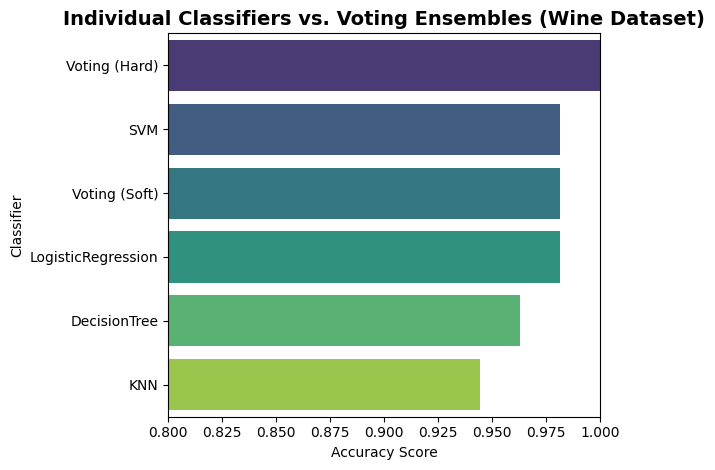

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_acc = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

sns.barplot(x='Accuracy', y='Model', data=df_acc, palette='viridis')
plt.xlim(0.8, 1.0)
plt.title('Individual Classifiers vs. Voting Ensembles (Wine Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy Score')
plt.ylabel('Classifier')
plt.tight_layout()
plt.show()


## Exercise 2: Visualizing Decision Boundaries — Single Tree vs. Bagging

Bagging smooths out decision boundaries, making them less jagged and reducing the high variance characteristic of single decision trees. Let's visualize this using a synthetic 2D dataset.

### Step 2.1: Generate Moons Dataset
We use `make_moons` to generate a non-linear class boundary.


In [9]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42
)
print("Synthetic moons dataset generated.")


Synthetic moons dataset generated.


### Step 2.2: Fit Single Decision Tree
Let's fit a single unconstrained tree, which will naturally overfit the noise.


In [10]:
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train_m, y_train_m)
print(f"Single Decision Tree Accuracy: {accuracy_score(y_test_m, single_tree.predict(X_test_m)):.4%}")


Single Decision Tree Accuracy: 82.0000%


### Step 2.3: Fit Bagging Classifier
Now let's fit a `BaggingClassifier` containing 100 Decision Trees.


In [11]:
from sklearn.ensemble import BaggingClassifier

bagging_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_tree.fit(X_train_m, y_train_m)
print(f"Bagged Decision Trees Accuracy: {accuracy_score(y_test_m, bagging_tree.predict(X_test_m)):.4%}")


Bagged Decision Trees Accuracy: 88.0000%


### Step 2.4: Plotting Decision Boundaries
Let's define a function to plot the decision boundary and run it.


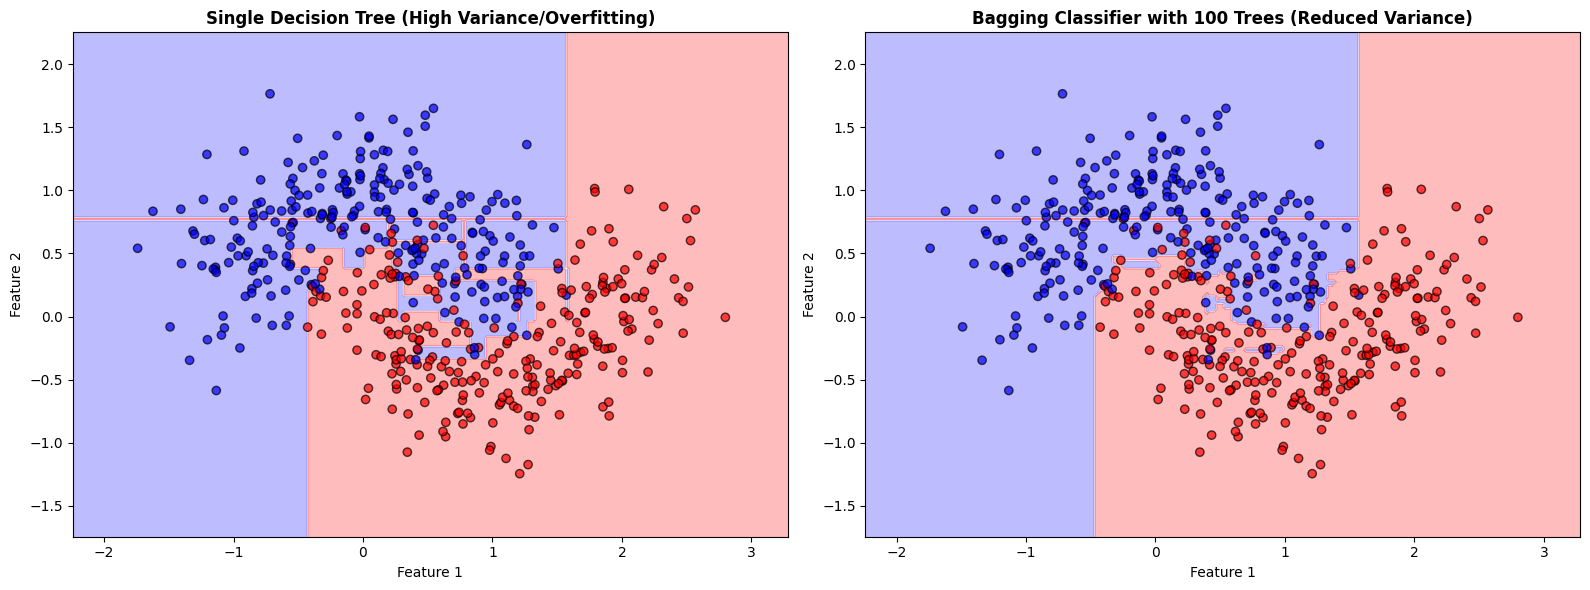

In [12]:
import numpy as np

def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='bwr', alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_decision_boundary(single_tree, X_moons, y_moons, axes[0], "Single Decision Tree (High Variance/Overfitting)")
plot_decision_boundary(bagging_tree, X_moons, y_moons, axes[1], "Bagging Classifier with 100 Trees (Reduced Variance)")
plt.tight_layout()
plt.show()


## Exercise 3: Out-of-Bag (OOB) Evaluation vs. Test Accuracy

Let's verify the mathematical usefulness of OOB score as an unbiased estimation of test set accuracy.


In [13]:
bagging_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200,
    bootstrap=True,
    oob_score=True, # Enable OOB score calculation
    n_jobs=-1,
    random_state=42
)
bagging_oob.fit(X_train_m, y_train_m)

oob_score = bagging_oob.oob_score_
test_accuracy = accuracy_score(y_test_m, bagging_oob.predict(X_test_m))

print(f"Out-of-Bag (OOB) Score: {oob_score:.4%}")
print(f"Actual Test Set Accuracy: {test_accuracy:.4%}")
print(f"Absolute Gap: {abs(oob_score - test_accuracy):.4%}")


Out-of-Bag (OOB) Score: 90.7500%
Actual Test Set Accuracy: 88.0000%
Absolute Gap: 2.7500%


## Exercise 4: Hyperparameter Sweep on `n_estimators`

Let's study the convergence of bagging. Does adding more trees indefinitely improve performance? Or does it plateau? We'll sweep values and plot them.


In [14]:
n_estimators_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300]
train_scores = []
test_scores = []
oob_scores = []

for n in n_estimators_range:
    b_clf = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        bootstrap=True,
        oob_score=True if n > 15 else False, # stable OOB requires enough trees
        n_jobs=-1,
        random_state=42
    )
    b_clf.fit(X_train_m, y_train_m)
    
    train_scores.append(accuracy_score(y_train_m, b_clf.predict(X_train_m)))
    test_scores.append(accuracy_score(y_test_m, b_clf.predict(X_test_m)))
    if n > 15:
        oob_scores.append(b_clf.oob_score_)
    else:
        oob_scores.append(np.nan)

print("Sweep finished. Plotting results...")


Sweep finished. Plotting results...


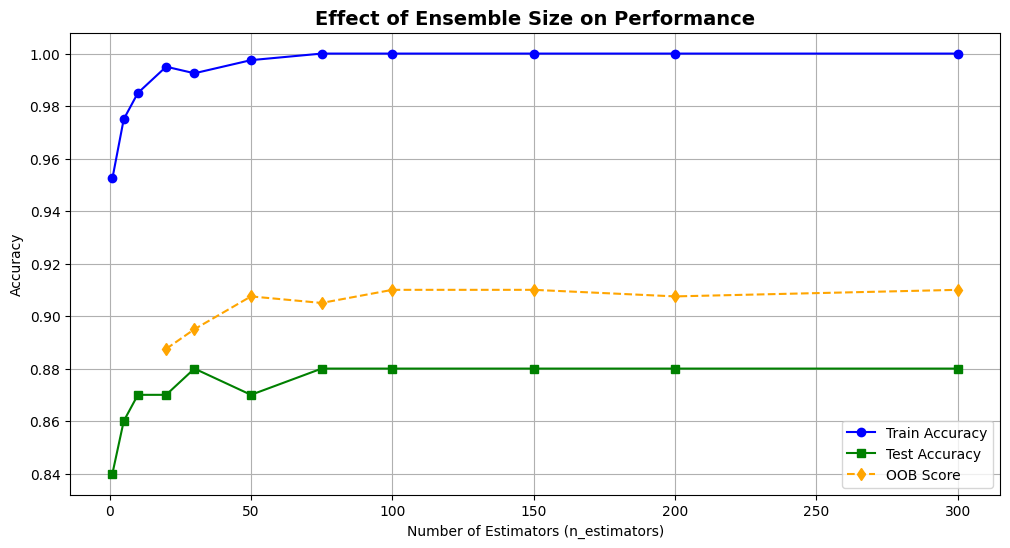

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, train_scores, 'o-', label='Train Accuracy', color='blue')
plt.plot(n_estimators_range, test_scores, 's-', label='Test Accuracy', color='green')
plt.plot(n_estimators_range, oob_scores, 'd--', label='OOB Score', color='orange')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Effect of Ensemble Size on Performance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()
